In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")
print(pd.DataFrame(df))

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")
print("first 5 rows")
print(df.head())
print("\nDataset shape")
print(df.shape)
print("\n Dataset description")
print(df.describe())
print(df.info())
print(df.isnull().sum)

first 5 rows
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset shape
(200, 5)

 Dataset description
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.0000

In [ ]:
X = df[['Annual Income (k$)','Spending Score (1-100)' ]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nScaled Features:")
print(X_scaled)
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print(df_scaled)
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)




Scaled Features:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378

In [ ]:
df_scaled.insert(0, 'CustomerID', df['CustomerID'])

print("Scaled data" ,df_scaled)

Scaled data      CustomerID  Annual Income (k$)  Spending Score (1-100)
0             1           -1.738999               -0.434801
1             2           -1.738999                1.195704
2             3           -1.700830               -1.715913
3             4           -1.700830                1.040418
4             5           -1.662660               -0.395980
..          ...                 ...                     ...
195         196            2.268791                1.118061
196         197            2.497807               -0.861839
197         198            2.497807                0.923953
198         199            2.917671               -1.250054
199         200            2.917671                1.273347

[200 rows x 3 columns]


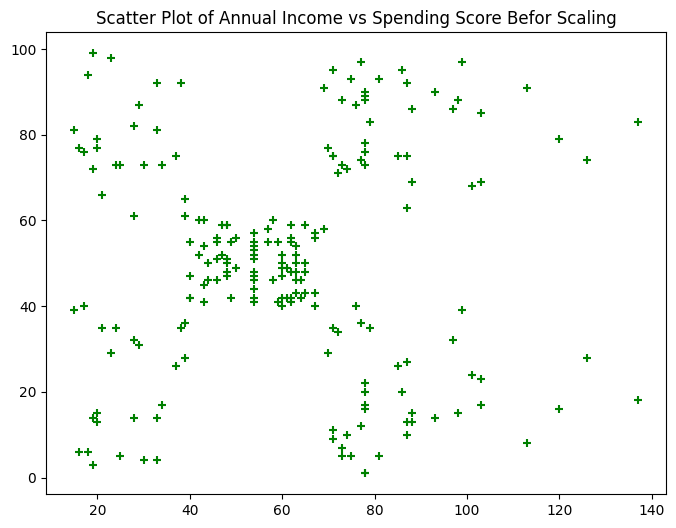

In [ ]:
plt.figure(figsize=(8, 6))
plt.title('Scatter Plot of Annual Income vs Spending Score Befor Scaling')
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],color='green', s=30,marker="+", label='Before Scaling')
plt.show()



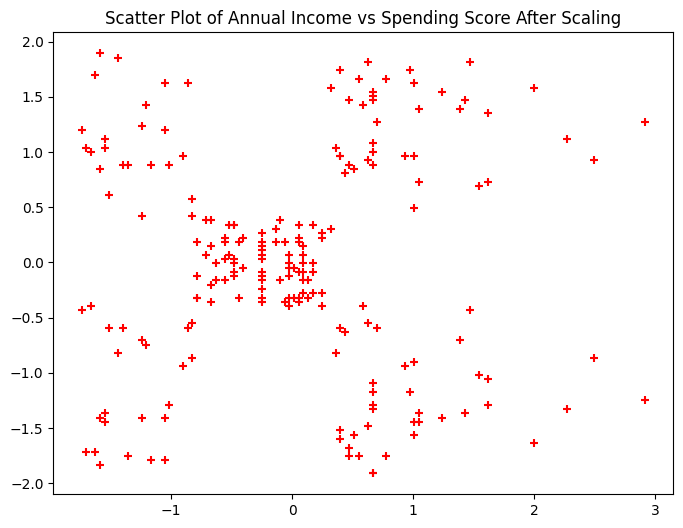

In [ ]:
plt.figure(figsize=(8, 6))
plt.title('Scatter Plot of Annual Income vs Spending Score After Scaling')
plt.scatter(df_scaled['Annual Income (k$)'], df_scaled['Spending Score (1-100)'],color='red', s=40,marker="+", label='After Scaling')
plt.show()

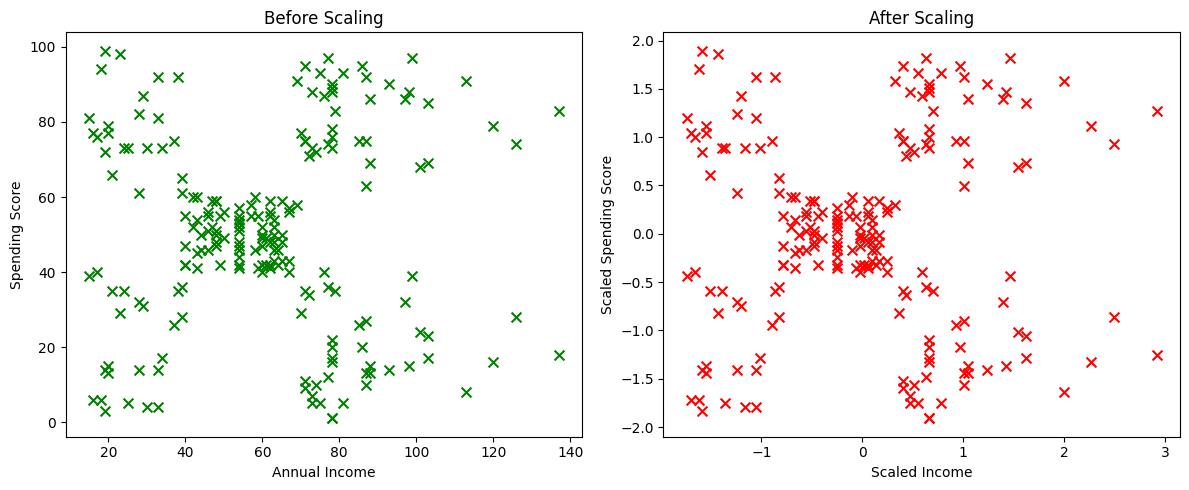

In [ ]:
plt.figure(figsize=(12, 5))

# Before Scaling
plt.subplot(1, 2, 1)
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    s=50,
    marker="x", color='green'

)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Before Scaling')

# After Scaling
plt.subplot(1, 2, 2)
plt.scatter(
    df_scaled['Annual Income (k$)'],
    df_scaled['Spending Score (1-100)'],
    s=50,
    marker="x", color='red'
)
plt.xlabel('Scaled Income')
plt.ylabel('Scaled Spending Score')
plt.title('After Scaling')

plt.tight_layout()
plt.show()

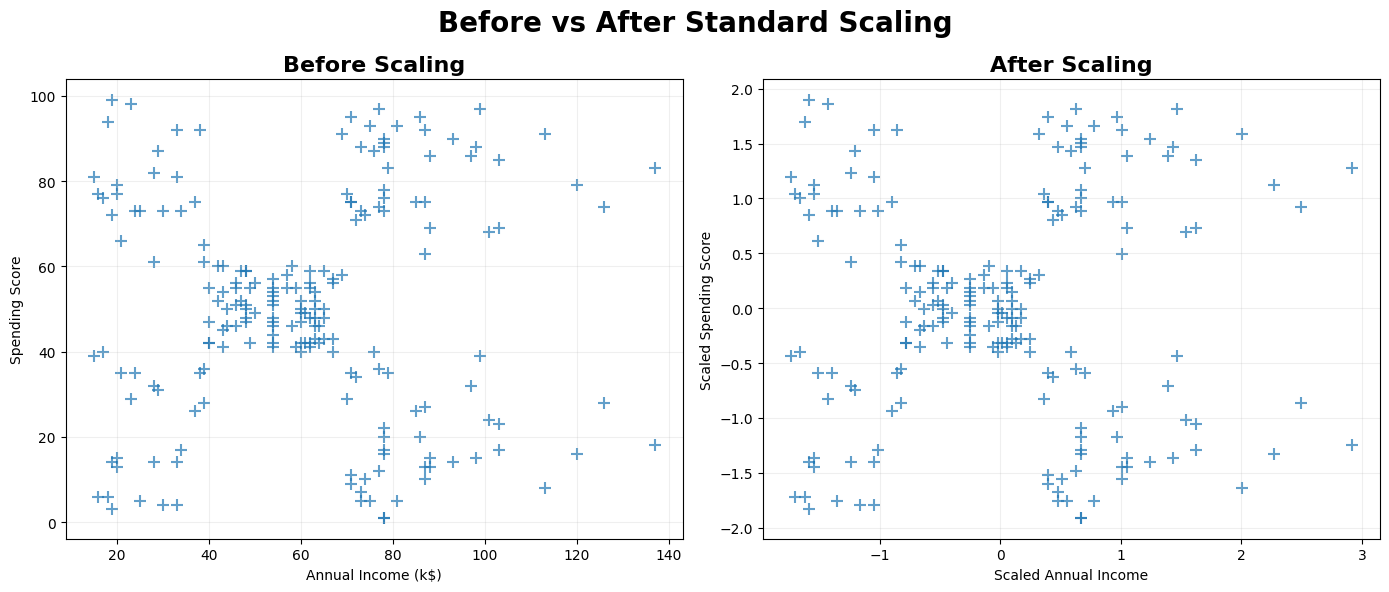


Elbow Method



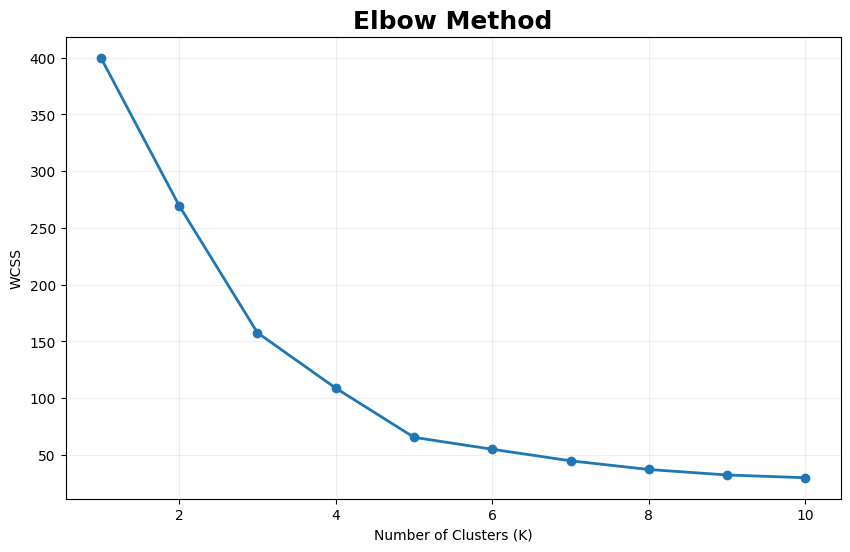


Final Dataset with Clusters:
     CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster
0             1                  15                      39        2
1             2                  15                      81        2
2             3                  16                       6        2
3             4                  16                      77        2
4             5                  17                      40        2
..          ...                 ...                     ...      ...
195         196                 120                      79        1
196         197                 126                      28        0
197         198                 126                      74        1
198         199                 137                      18        0
199         200                 137                      83        1

[200 rows x 4 columns]


/tmp/ipykernel_566/3636995802.py:147: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


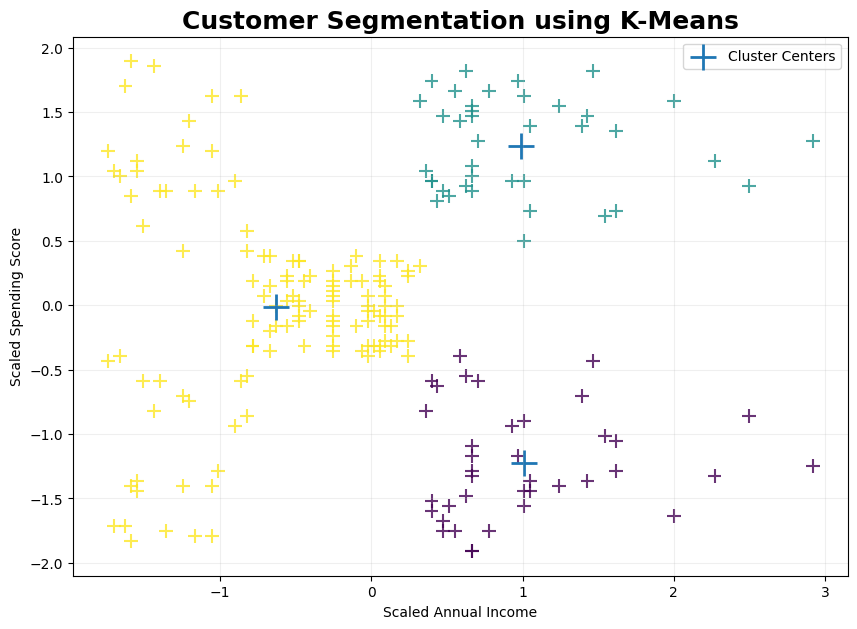


Customers in Each Cluster:
Cluster
0     38
1     39
2    123
Name: count, dtype: int64


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))


# BEFORE SCALING
ax[0].scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    s=80,
    alpha=0.7,
    marker="+"
)

ax[0].set_title(
    "Before Scaling",
    fontsize=16,
    fontweight='bold'
)

ax[0].set_xlabel("Annual Income (k$)")
ax[0].set_ylabel("Spending Score")
ax[0].grid(alpha=0.2)


# AFTER SCALING
ax[1].scatter(
    df_scaled['Annual Income (k$)'],
    df_scaled['Spending Score (1-100)'],
    s=80,
    alpha=0.7,
    marker="+"
)

ax[1].set_title(
    "After Scaling",
    fontsize=16,
    fontweight='bold'
)

ax[1].set_xlabel("Scaled Annual Income")
ax[1].set_ylabel("Scaled Spending Score")
ax[1].grid(alpha=0.2)


plt.suptitle(
    "Before vs After Standard Scaling",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()
plt.show()
print("\nElbow Method\n")


# ==========================================
# STEP 6: ELBOW METHOD
# ==========================================

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)


plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker='o',
    linewidth=2
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.title(
    "Elbow Method",
    fontsize=18,
    fontweight='bold'
)

plt.grid(alpha=0.2)
plt.show()



# ==========================================
# STEP 7: K-MEANS
# ==========================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)


# ==========================================
# STEP 8: DISPLAY CLUSTERS
# ==========================================

print("\nFinal Dataset with Clusters:")

print(
    df[
        [
            'CustomerID',
            'Annual Income (k$)',
            'Spending Score (1-100)',
            'Cluster'
        ]
    ]
)


# ==========================================
# STEP 9: FINAL CLUSTER GRAPH
# ==========================================

plt.figure(figsize=(10, 7))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=df['Cluster'],
    s=100,
    marker="+",
    alpha=0.8
)


# Cluster centers
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='+',
    s=350,
    edgecolor='red',
    linewidth=2,
    label='Cluster Centers'
)


plt.xlabel("Scaled Annual Income")
plt.ylabel("Scaled Spending Score")

plt.title(
    "Customer Segmentation using K-Means",
    fontsize=18,
    fontweight='bold'
)

plt.legend()
plt.grid(alpha=0.2)

plt.show()


# ==========================================
# STEP 10: COUNT CUSTOMERS PER CLUSTER
# ==========================================

print("\nCustomers in Each Cluster:")

print(
    df['Cluster']
    .value_counts()
    .sort_index()
)

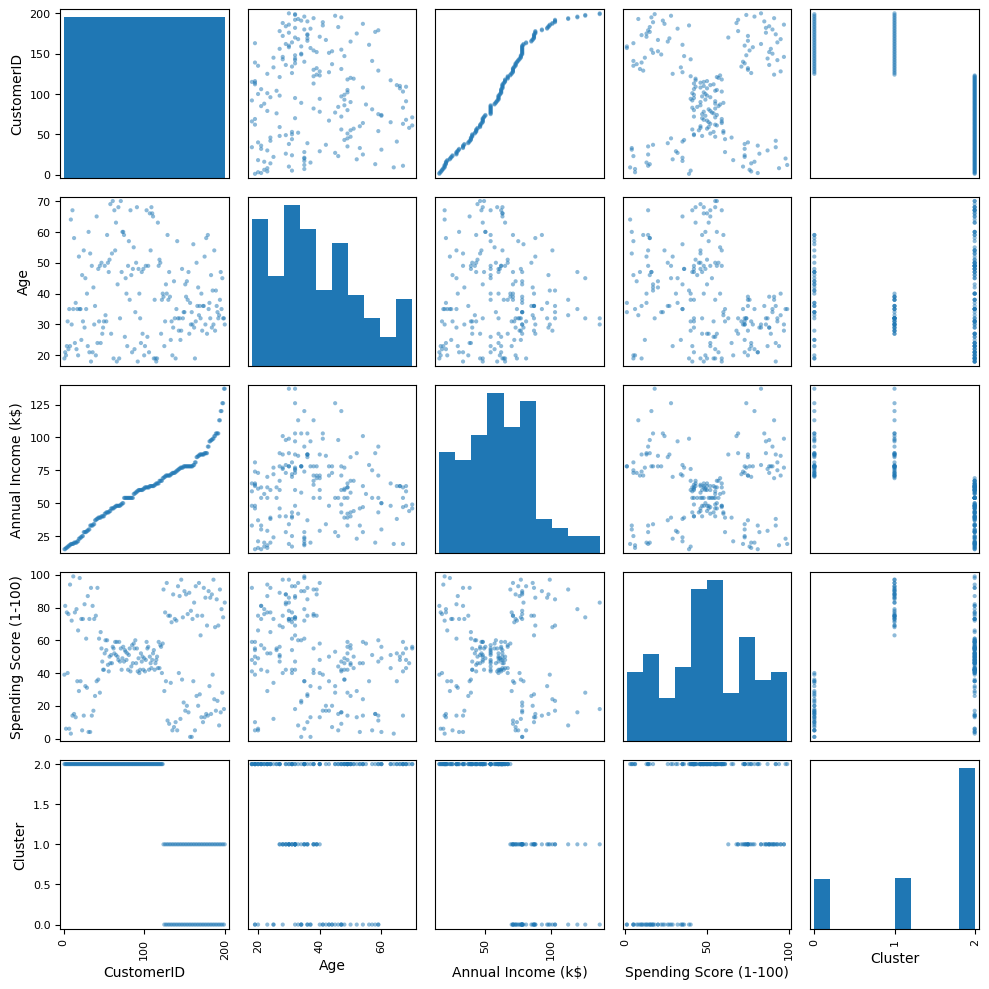

In [ ]:
import matplotlib.pyplot as plt
numeric_data=df.select_dtypes(include='number')
pd.plotting.scatter_matrix(numeric_data,figsize=(10,10))
plt.tight_layout()
plt.show()

In [ ]:
X=df.iloc[:,[3,4]]
# x=df[['Annual income', 'Spending Score']]
print(X)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


In [ ]:
X_scaled_df=pd.DataFrame(X_scaled,columns=['AnnualscaledIncome', 'ScaledSpending'])
print(X_scaled_df.head())

   AnnualscaledIncome  ScaledSpending
0           -1.738999       -0.434801
1           -1.738999        1.195704
2           -1.700830       -1.715913
3           -1.700830        1.040418
4           -1.662660       -0.395980


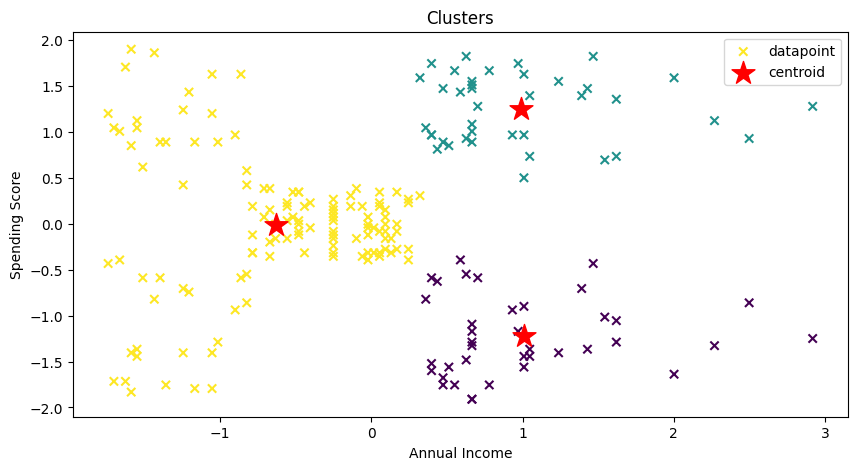

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=kmeans.labels_, marker="x", label="datapoint")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Clusters")
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],marker="*", s=300,c='red',label='centroid')
plt.legend()
plt.show()
